# Amazon Closing-Price Prediction with a PyTorch LSTM

## Objective
Build a univariate LSTM regression model that predicts the next trading day's closing price from the previous seven observed closing prices.

This is a sequence-modeling learning project. Each prediction uses observed historical prices; the notebook does not recursively forecast the entire test period from a single starting date.

## Input data
This notebook reads `Amazon_stock_closing_prices.csv`, generated by the EDA notebook. Run the EDA notebook first if this file is unavailable.

## Experiment configuration
- Input feature: closing price
- Lookback: seven trading observations
- Forecast horizon: one trading observation
- Chronological split: 95% training and 5% testing
- Model: one LSTM layer with four hidden units and a linear output layer
- Loss function: mean squared error
- Optimizer: Adam
- Learning rate: 0.001
- Batch size: 32
- Training duration: 15 epochs

## Dependencies
Python, pandas, NumPy, Matplotlib, scikit-learn, and PyTorch.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from copy import deepcopy as dc
import pandas as pd
import random
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [3]:
df = pd.read_csv('Amazon_stock_closing_prices.csv')

In [4]:
df

,Date,Close
0,1997-05-15,0.097917
1,1997-05-16,0.086458
2,1997-05-19,0.085417
3,1997-05-20,0.081771
4,1997-05-21,0.071354
...,...,...
6511,2023-03-30,102.000000
6512,2023-03-31,103.290001
6513,2023-04-03,102.410004
6514,2023-04-04,103.949997


In [5]:
df.Date.info()

<class 'pandas.Series'>
RangeIndex: 6516 entries, 0 to 6515
Series name: Date
Non-Null Count  Dtype
--------------  -----
6516 non-null   str  
dtypes: str(1)
memory usage: 51.0 KB


In [6]:
df.Date = pd.to_datetime(df['Date'])
df.index = df.Date

In [7]:
df.drop(['Date'], axis=1, inplace=True)

In [8]:
df

,Close
Date,
1997-05-15,0.097917
1997-05-16,0.086458
1997-05-19,0.085417
1997-05-20,0.081771
1997-05-21,0.071354
...,...
2023-03-30,102.000000
2023-03-31,103.290001
2023-04-03,102.410004


In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

## Constructing prediction windows

Each example pairs seven previous closing prices with the closing price to predict. Rows without enough historical observations are removed.

The resulting dataset contains 6,509 examples. LSTM inputs have shape `(samples, 7, 1)`, representing seven timesteps and one feature per timestep. Targets have shape `(samples, 1)`.

In [10]:
def prepare_dataframe_for_lstm(df, n_steps):
    df = dc(df)

    for i in range(1, n_steps+1):
        df[f'Close(t-{i})'] = df['Close'].shift(i)

    df.dropna(inplace=True)

    return df

lookback = 7
shifted_df = prepare_dataframe_for_lstm(df, lookback)
shifted_df

,Close,Close(t-1),Close(t-2),Close(t-3),Close(t-4),Close(t-5),Close(t-6),Close(t-7)
Date,,,,,,,,
1997-05-27,0.079167,0.075000,0.069792,0.071354,0.081771,0.085417,0.086458,0.097917
1997-05-28,0.076563,0.079167,0.075000,0.069792,0.071354,0.081771,0.085417,0.086458
1997-05-29,0.075260,0.076563,0.079167,0.075000,0.069792,0.071354,0.081771,0.085417
1997-05-30,0.075000,0.075260,0.076563,0.079167,0.075000,0.069792,0.071354,0.081771
1997-06-02,0.075521,0.075000,0.075260,0.076563,0.079167,0.075000,0.069792,0.071354
...,...,...,...,...,...,...,...,...
2023-03-30,102.000000,100.250000,97.239998,98.040001,98.129997,98.709999,98.699997,100.610001
2023-03-31,103.290001,102.000000,100.250000,97.239998,98.040001,98.129997,98.709999,98.699997
2023-04-03,102.410004,103.290001,102.000000,100.250000,97.239998,98.040001,98.129997,98.709999


In [11]:
import numpy as np
shifted_df = np.array(shifted_df)
print(shifted_df)
print('-----------------------------')
print(shifted_df.shape)

[[7.91670000e-02 7.50000000e-02 6.97920000e-02 ... 8.54170000e-02
  8.64580000e-02 9.79170000e-02]
 [7.65630000e-02 7.91670000e-02 7.50000000e-02 ... 8.17710000e-02
  8.54170000e-02 8.64580000e-02]
 [7.52600000e-02 7.65630000e-02 7.91670000e-02 ... 7.13540000e-02
  8.17710000e-02 8.54170000e-02]
 ...
 [1.02410004e+02 1.03290001e+02 1.02000000e+02 ... 9.80400010e+01
  9.81299970e+01 9.87099990e+01]
 [1.03949997e+02 1.02410004e+02 1.03290001e+02 ... 9.72399980e+01
  9.80400010e+01 9.81299970e+01]
 [1.01099998e+02 1.03949997e+02 1.02410004e+02 ... 1.00250000e+02
  9.72399980e+01 9.80400010e+01]]
-----------------------------
(6509, 8)


In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
shifted_df = scaler.fit_transform(shifted_df)

In [13]:
X = shifted_df[:, 1:]
y = shifted_df[:, 0]

X.shape, y.shape

((6509, 7), (6509,))

In [14]:
X = dc(np.flip(X, axis=1))
X

array([[-0.65434532, -0.65482206, -0.65508275, ..., -0.65585422,
        -0.65612616, -0.65625738],
       [-0.65458392, -0.65484373, -0.65515864, ..., -0.65588673,
        -0.65601779, -0.65617068],
       [-0.65460559, -0.65491964, -0.65537549, ..., -0.65577835,
        -0.65593109, -0.65622486],
       ...,
       [ 1.39888892,  1.38634806,  1.38398218, ...,  1.42894424,
         1.46484   ,  1.49114011],
       [ 1.38681251,  1.38447443,  1.36732897, ...,  1.46536316,
         1.49168238,  1.47283169],
       [ 1.38493867,  1.36781915,  1.42998647, ...,  1.49220912,
         1.47337138,  1.50487139]], shape=(6509, 7))

In [15]:
split_index = int(len(X) * 0.95)

split_index

6183

In [16]:
X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6183, 7), (326, 7), (6183,), (326,))

In [17]:
X_train = X_train.reshape((-1, lookback, 1))
X_test = X_test.reshape((-1, lookback, 1))

y_train = y_train.reshape((-1, 1))
y_test = y_test.reshape((-1, 1))

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6183, 7, 1), (326, 7, 1), (6183, 1), (326, 1))

In [18]:
X_train = torch.tensor(X_train).float()
y_train = torch.tensor(y_train).float()
X_test = torch.tensor(X_test).float()
y_test = torch.tensor(y_test).float()

X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([6183, 7, 1]),
 torch.Size([326, 7, 1]),
 torch.Size([6183, 1]),
 torch.Size([326, 1]))

In [19]:
class CustomDataset(Dataset):
    def __init__(self,x,y):
        self.x = x
        self.y = y
    def __len__(self):
        return(len(self.x))
    def __getitem__(self,idx):
        return self.x[idx],self.y[idx]

train_dataset = CustomDataset(X_train,y_train)
test_dataset = CustomDataset(X_test,y_test)

In [ ]:
train_loader = DataLoader( train_dataset, batch_size = 32 , shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = True)

## LSTM architecture

The LSTM processes each input sequence and produces a hidden representation at every timestep. A linear layer maps the final timestep's representation to one predicted closing price.

Hidden and cell states are reset for each batch, so information is not carried between separate windows.

In [21]:
class LSTMModel(nn.Module):
    def __init__(self,input_size, hidden_size , num_layers):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size , hidden_size , num_layers , batch_first = True)
        self.fc = nn.Linear(hidden_size , 1)

    def forward(self,x):
        h0 = torch.zeros(self.num_layers , x.size(0) , self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers , x.size(0) , self.hidden_size).to(device)

        out , _ = self.lstm(x , (h0,c0))
        out = self.fc(out[:,-1,:])
        return out

In [22]:
model = LSTMModel( 1 ,4 , 1).to(device)
model

LSTMModel(
  (lstm): LSTM(1, 4, batch_first=True)
  (fc): Linear(in_features=4, out_features=1, bias=True)
)

## Training and loss monitoring

During training, Adam updates the model parameters to minimize mean squared error. Evaluation runs without gradient computation.

Epoch losses are weighted by batch size before averaging across observations. Because prices are standardized, the reported MSE values are in standardized units rather than original price units.

In [23]:
train_loss_curve = []
test_loss_curve = []

def train(model_used, epochs=15):
    loss_fn = nn.MSELoss()
    optimiser = optim.Adam(model_used.parameters(), lr=0.001)

    for epoch in range(epochs):
        model_used.train()
        train_loss = 0.0

        for data, target in train_loader:
            data = data.to(device)
            target = target.to(device)

            optimiser.zero_grad()

            output = model_used(data)
            loss = loss_fn(output, target)

            loss.backward()
            optimiser.step()

            train_loss += loss.item() * data.size(0)

        train_loss /= len(train_loader.dataset)
        train_loss_curve.append(train_loss)

        model_used.eval()
        test_loss = 0.0

        with torch.inference_mode():
            for data, target in test_loader:
                data = data.to(device)
                target = target.to(device)

                output = model_used(data)
                loss = loss_fn(output, target)

                test_loss += loss.item() * data.size(0)

        test_loss /= len(test_loader.dataset)
        test_loss_curve.append(test_loss)

        print(
            f"Epoch {epoch + 1:02d} | "
            f"Train MSE: {train_loss:.6f} | "
            f"Test MSE: {test_loss:.6f}"
        )

train(model)

Epoch 01 | Train MSE: 0.546111 | Test MSE: 1.203103
Epoch 02 | Train MSE: 0.171681 | Test MSE: 0.406938
Epoch 03 | Train MSE: 0.089211 | Test MSE: 0.203034
Epoch 04 | Train MSE: 0.050062 | Test MSE: 0.092824
Epoch 05 | Train MSE: 0.022792 | Test MSE: 0.040892
Epoch 06 | Train MSE: 0.009451 | Test MSE: 0.032507
Epoch 07 | Train MSE: 0.004906 | Test MSE: 0.031921
Epoch 08 | Train MSE: 0.003082 | Test MSE: 0.022001
Epoch 09 | Train MSE: 0.002171 | Test MSE: 0.021198
Epoch 10 | Train MSE: 0.001730 | Test MSE: 0.018636
Epoch 11 | Train MSE: 0.001540 | Test MSE: 0.020311
Epoch 12 | Train MSE: 0.001411 | Test MSE: 0.016794
Epoch 13 | Train MSE: 0.001325 | Test MSE: 0.015544
Epoch 14 | Train MSE: 0.001236 | Test MSE: 0.014440
Epoch 15 | Train MSE: 0.001170 | Test MSE: 0.014781


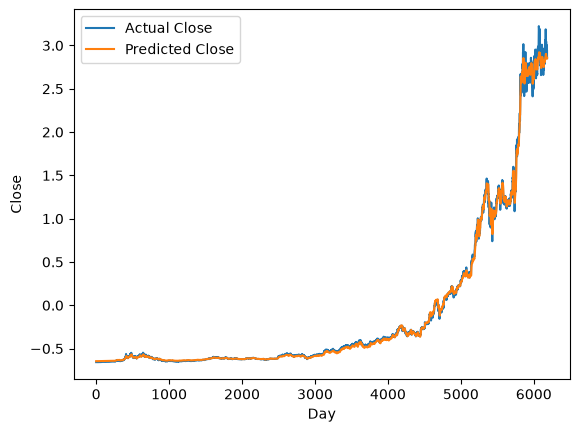

In [24]:
with torch.no_grad():
    predicted = model(X_train.to(device)).to('cpu').numpy()

plt.plot(y_train, label='Actual Close')
plt.plot(predicted, label='Predicted Close')
plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()
plt.show()